# The Iris Dataset
The Iris dataset is a classic dataset in machine learning that contains measurements of different flower species to classify them based on their features. It was originally introduced by Ronald A. Fisher in 1936 for statistical analysis.
It consists of 150 samples of iris flowers, divided equally among 3 species: setosa, versicolor, and virginica.

Each sample includes 4 features:
*   Sepal length (in cm)
*   Sepal width (in cm)
*   Petal length (in cm)
*   Petal width (in cm)

In [18]:
import pandas as pd
from sklearn.datasets import load_iris
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt

# Load the Iris dataset
iris = load_iris()

# Convert into Pandas dataframe
df = pd.DataFrame(iris.data, columns=iris.feature_names)

# Shuffle and print the first 5 rows
shuffled_df = df.sample(frac=1)
print(shuffled_df.head())

# Convert numerical class labels in the Iris dataset into human-readable labels
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)
print(df.head())

# Limit data to only two species for now
df = df[df['species'] != 'setosa']

# Create and train the model
# Extract features (X) and target (y)
X = df[['petal width (cm)', 'petal length (cm)']]
y = df['species']

# Train a logistic regression model
model = LogisticRegression(max_iter=100)
model.fit(X, y)

# Example prediction
sample = [[1.4, 4.25]]
prediction = model.predict(sample)
probabilities = model.predict_proba(sample)
print("Predicted class:", prediction)
print("Prediction probabilities", probabilities)


     sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)
61                 5.9               3.0                4.2               1.5
70                 5.9               3.2                4.8               1.8
139                6.9               3.1                5.4               2.1
122                7.7               2.8                6.7               2.0
55                 5.7               2.8                4.5               1.3
   sepal length (cm)  sepal width (cm)  petal length (cm)  petal width (cm)  \
0                5.1               3.5                1.4               0.2   
1                4.9               3.0                1.4               0.2   
2                4.7               3.2                1.3               0.2   
3                4.6               3.1                1.5               0.2   
4                5.0               3.6                1.4               0.2   

  species  
0  setosa  
1  setosa  
2  setosa  
3  setosa

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


# Binary Cross Entropy

In [5]:
from sklearn.metrics import log_loss

# Fit the model again and collect the prediction probabilities
y_predicted = model.fit(X, y).predict_proba(X)

# Calculate Binary Cross-Entropy loss
loss = log_loss(y, y_predicted)

print(f"Binary Cross-Entropy Loss {loss}")

Binary Cross-Entropy Loss 0.17874075863181083


## Plot loss-log graph of BCE

/usr/local/lib/python3.11/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


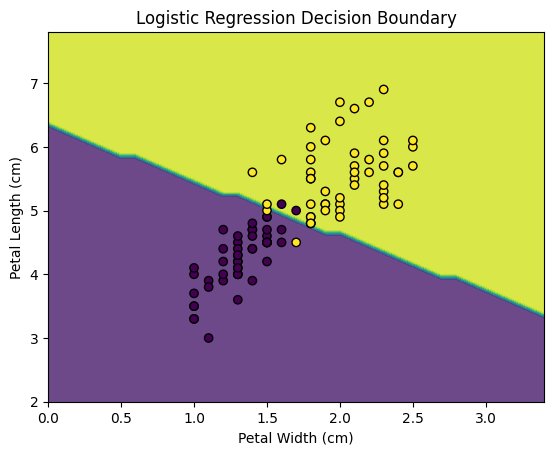

In [11]:
import numpy as np
from sklearn.preprocessing import LabelEncoder

# Convert string labels to numerical labels

le = LabelEncoder()
y_numeric = le.fit_transform(y)

# Create meshgrid and plot decision boundary
x_min, x_max = X['petal width (cm)'].min() - 1, X['petal width (cm)'].max() + 1
y_min, y_max = X['petal length (cm)'].min() - 1, X['petal length (cm)'].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.1),
                     np.arange(y_min, y_max, 0.1))

# Predict labels
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])

# Convert predicted labels back to numerical labels
Z_numeric = le.transform(Z)
Z_numeric = Z_numeric.reshape(xx.shape)

plt.contourf(xx, yy, Z_numeric, alpha=0.8)
plt.scatter(X['petal width (cm)'], X['petal length (cm)'], c=y_numeric, edgecolors='k')
plt.xlabel('Petal Width (cm)')
plt.ylabel('Petal Length (cm)')
plt.title('Logistic Regression Decision Boundary')
plt.show()